# Brain Tumor Classification

## Library Imports

In [ ]:
import os

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

## Dataset Acquisition

In [3]:
dataset_source = "sartajbhuvaji/brain-tumor-classification-mri"
dataset_path = kagglehub.dataset_download(dataset_source)

print("Path to Dataset:", dataset_path)

Path to Dataset: /home/zen/.cache/kagglehub/datasets/sartajbhuvaji/brain-tumor-classification-mri/versions/3


## Dataset Splitting

In [4]:
train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Testing")

classes = os.listdir(train_path)

print(classes)

['meningioma_tumor', 'glioma_tumor', 'pituitary_tumor', 'no_tumor']


## Preprocessing

In [5]:
def preprocess(datapath, label, X, y, idx):
  images = glob(os.path.join(datapath, label, "*.jpg"))

  for i in images:
    img = cv.imread(i)
    img_resized = cv.resize(img, (128, 128))
    img_grayscale = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)

    # TODO: normalize

    X.append(img_grayscale)
    y.append(idx)

In [6]:
X, y = [], []
X_test, y_test = [], []

for idx, label in enumerate(classes):
  preprocess(train_path, label, X, y, idx)
  preprocess(test_path, label, X_test, y_test, idx)

print(len(X), len(y))
print(len(X_test), len(y_test))

2870 2870
394 394


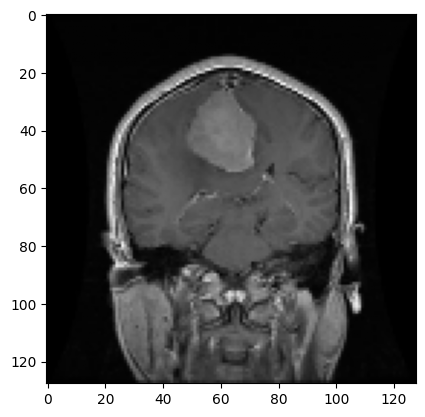

In [7]:
plt.imshow(X[0], cmap="gray")

### Data Splitting

In [8]:

X_train, X_val, y_train, y_val = train_test_split(
  X, y, 
  test_size=0.2,
  random_state=42)

X_train[:5]

[array([[0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 4, 2, 2],
        [1, 1, 1, ..., 4, 3, 3],
        ...,
        [2, 4, 4, ..., 3, 2, 2],
        [2, 2, 2, ..., 3, 2, 2],
        [0, 0, 0, ..., 1, 0, 0]], shape=(128, 128), dtype=uint8),
 array([[ 2,  2,  1, ...,  1,  1,  1],
        [ 4,  4,  6, ...,  4,  4,  4],
        [ 6,  9,  7, ...,  6,  8,  7],
        ...,
        [ 4,  6,  5, ..., 10,  8,  6],
        [ 2,  2,  2, ...,  6,  7,  4],
        [ 1,  1,  1, ...,  1,  1,  1]], shape=(128, 128), dtype=uint8),
 array([[107, 107, 107, ..., 108, 107, 176],
        [  1,   1,   1, ...,   1,  11, 128],
        [  2,   2,   2, ...,   8,   8, 126],
        ...,
        [  3,   2,   2, ...,   3,   0, 121],
        [  2,   2,   1, ...,  11,  10, 126],
        [107, 106, 106, ..., 105,  99, 182]], shape=(128, 128), dtype=uint8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 2, 2, 2],
        [1, 1, 1, ..., 2, 2, 2],
        ...,
        [0, 0, 1, ..., 2, 2, 2],
        [0, 0, 

## Feature Extraction
### Local Binary Pattern

In [9]:
def calculate_lbp(img, center, x, y):
  try:
    if(img[x][y] >= center):
      return 1
  except:
    pass

  return 0

def count_lbp(img, x, y):
  val_pix = []
  center = img[x, y]

  pixels = [(x-1, y-1), (x-1, y), (x-1, y+1),
            (  x, y-1),           (  x, y+1),
            (x+1, y-1), (x+1, y), (x+1, y+1)]
  
  for p in pixels:
    val_pix.append(calculate_lbp(img, center, p[0], p[1]))

  val_lbp = 0

  pows = [1, 2, 4, 8, 16, 32, 64, 128]

  for i in range(len(val_pix)):
    val_lbp += val_pix[i] * pows[i]

  return val_lbp

def lbp(img):
  height, width = img.shape
  img_lbp = np.zeros((height, width), np.uint8)

  for i in range(len(img)):
    for j in range(len(img[0])):
      pixel_lbp = count_lbp(img, i, j)
      img_lbp[i][j] = pixel_lbp

  return img_lbp

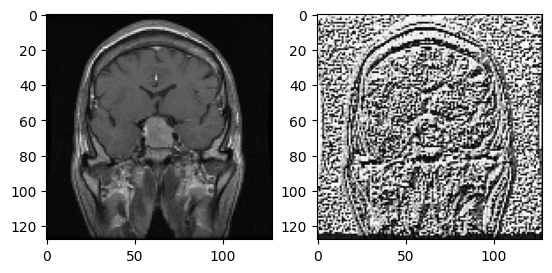

In [10]:
img_dum = X_train[20]
img_lbp = lbp(img_dum)

plt.subplot(1, 2, 1)
plt.imshow(img_dum, cmap="gray")

plt.subplot(1, 2, 2)
plt.imshow(img_lbp, cmap="gray")

## Classification

### Support Vector Machine

In [11]:
classifier = SVC()
classifier.fit(X_train, y_train)

classifier.predict(X_test[1])

ValueError: Found array with dim 3, while dim <= 2 is required by SVC.